In [ ]:
%load_ext autoreload
%autoreload 2
import sys
from IPython.display import HTML, Video, display
from csbdeep.utils import normalize
import re
from datetime import datetime

sys.path.append("..")
from src import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# DeepCAD-RT Training on Synthetic Dataset

ℹ️ This notebook visualizes the trainings made with [deepcad_train.py](deepcad_train.py).

Please refer to the script to run the training.

## 1. Comparing different values of `patch_t`

In [ ]:
# Change this with your own (label, training_name) entries
trainings = {
    # "patcht_600": "synthetic_202509211216",
    "patcht_300": "synthetic_202509211437",
    "patcht_150": "synthetic_202509211433",
    "patcht_75": "synthetic_202509211436",
    "patcht_30": "synthetic_202509211220",
    "patcht_15": "synthetic_202509211352",
}

In [ ]:
evals = {}
for k, training in trainings.items():
    evals[k] = sorted(Path(f"pth/{training}").glob("xf_*.tif"))
    duration = 0
    if evals[k]:
        start = datetime.fromtimestamp(evals[k][0].stat().st_ctime)
        end = datetime.fromtimestamp(evals[k][-1].stat().st_ctime)
        duration = end - start
    cprint(
        f"red:{k:10}",
        "-->",
        f"green:{len(evals[k]):2} epochs",
        f"yellow:duration={duration}",
    )

patcht_300 --> 10 epochs , duration=0:48:05
patcht_150 --> 10 epochs , duration=0:24:10
patcht_75  --> 10 epochs , duration=0:13:16
patcht_30  --> 10 epochs , duration=0:10:59
patcht_15  --> 10 epochs , duration=0:06:17


`patch_t` has an approximately linear impact on the time cost of training, so it is our interest to keep it as low as possible.

- `train_datasets_size`=$1{,}200$
- `select_img_num`=$1{,}000$

|patch_t|Epoch duration (sec) $\downarrow$|PSNR3D (dB) $\uparrow$|SSIM3D $\uparrow$|
|--|:--:|:--:|:--:|
|$300$|$316$|$32.71$|$0.826$|
|$150$|$157$|$32.85$|$0.823$|
|$75$|$78$|$32.47$|$0.811$|
|$30$|$65.9$|$31.60$|$0.799$|
|$15$|$37.7$|$27.80$|$0.738$|

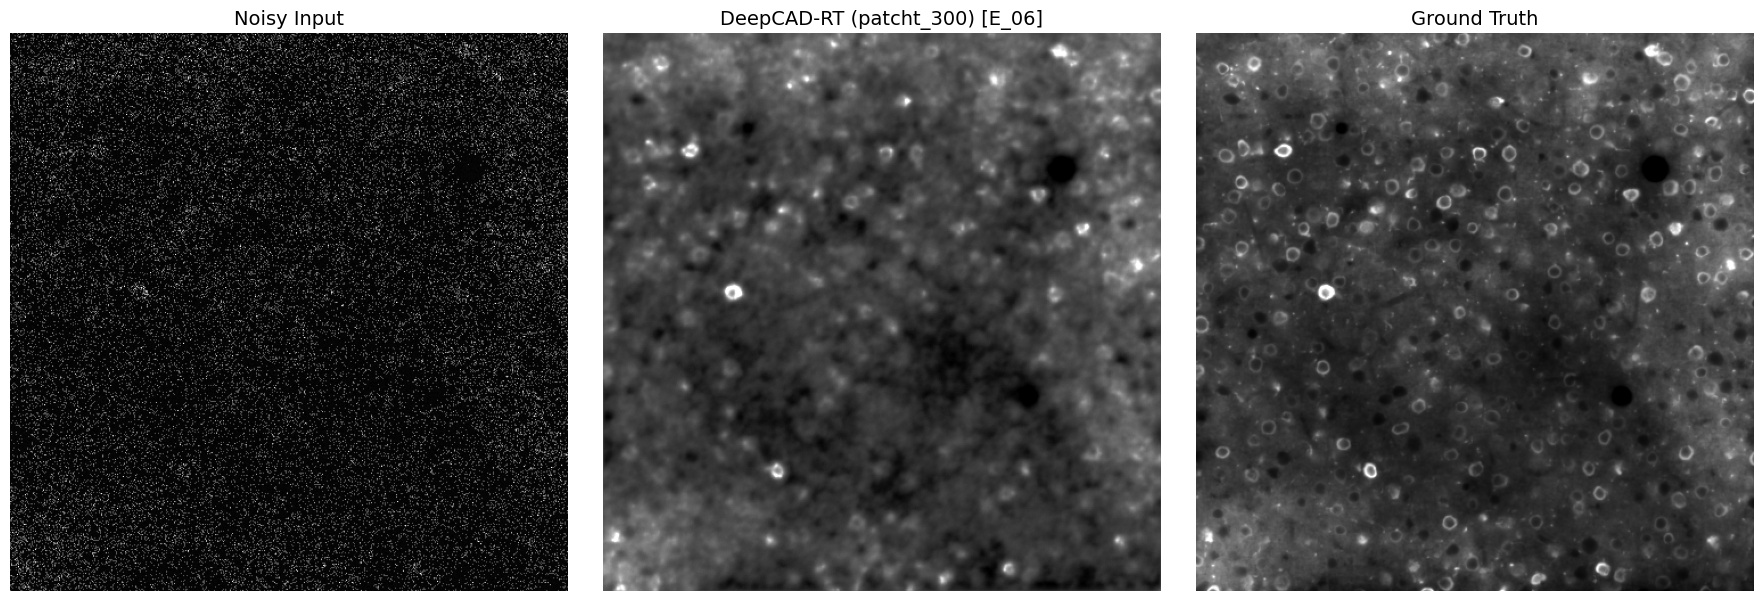

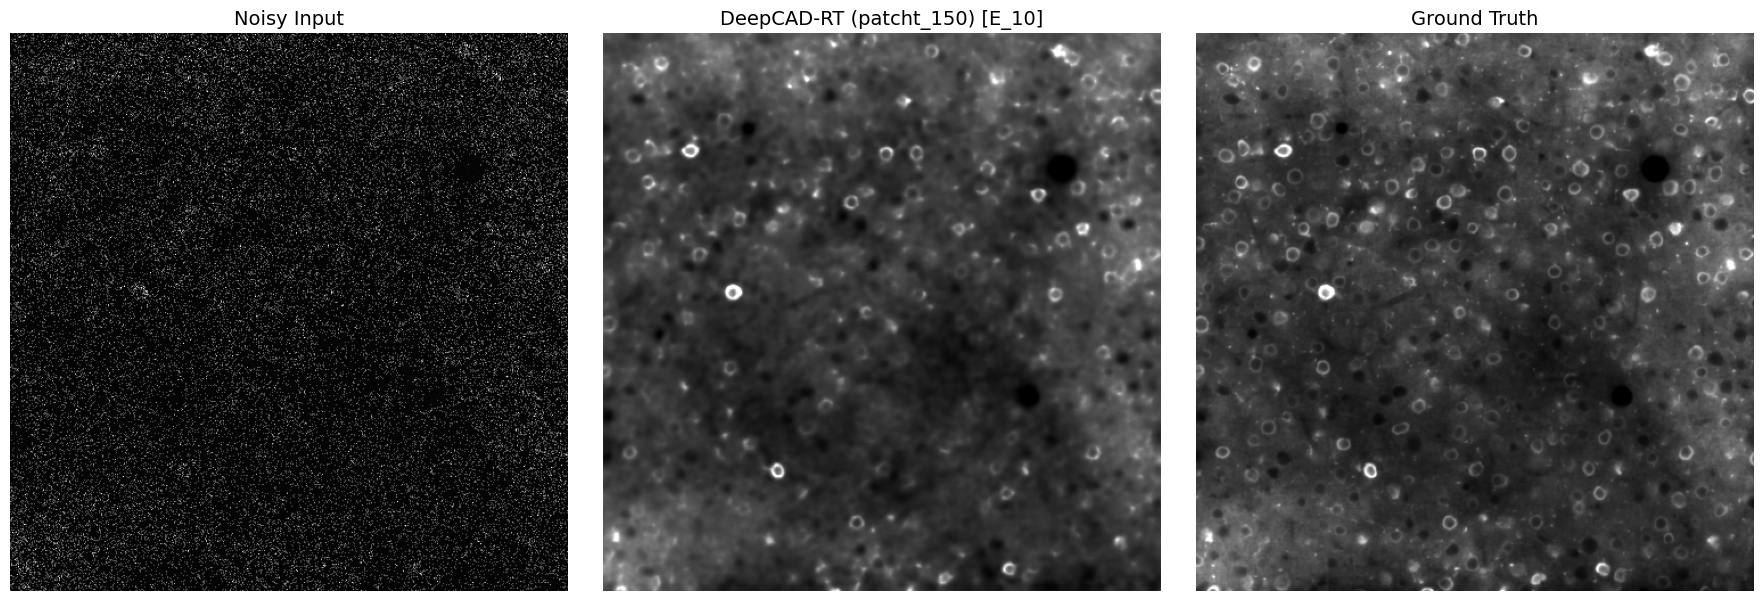

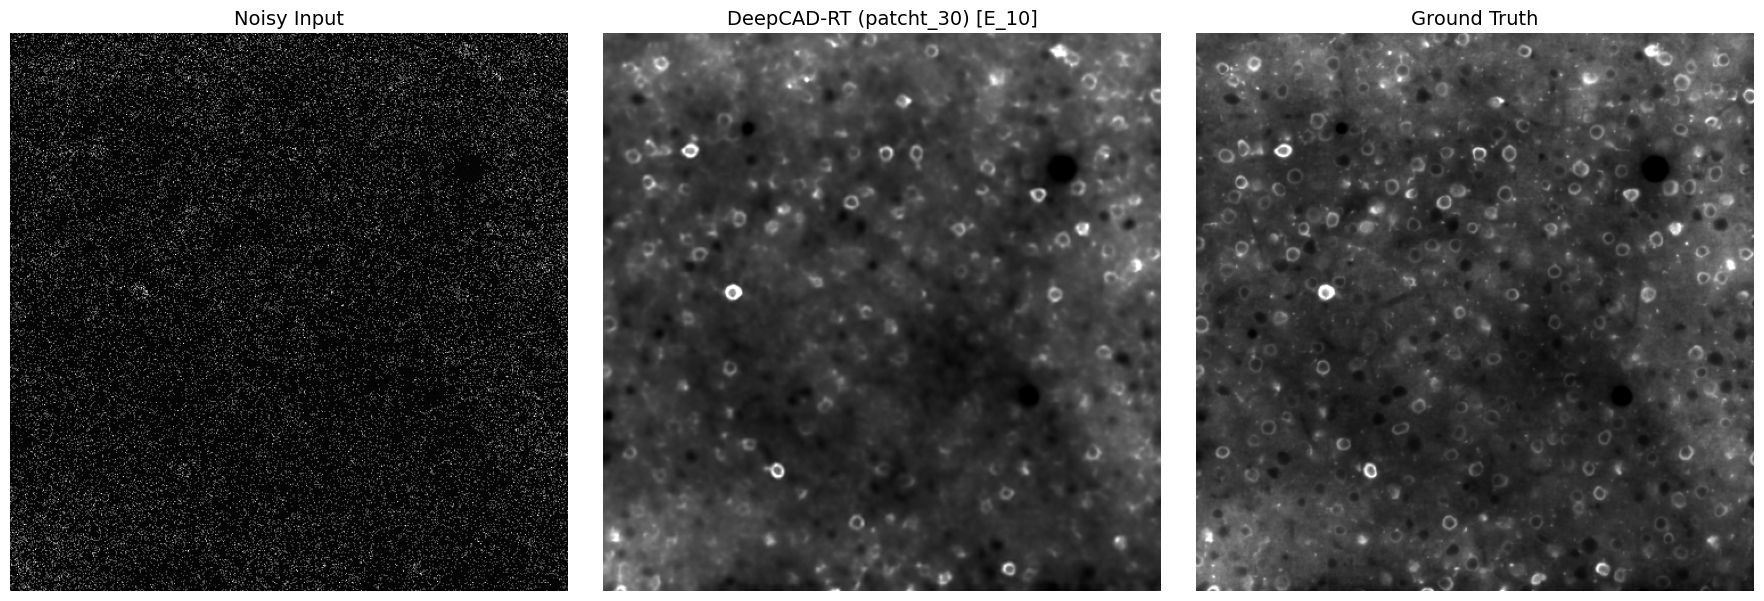

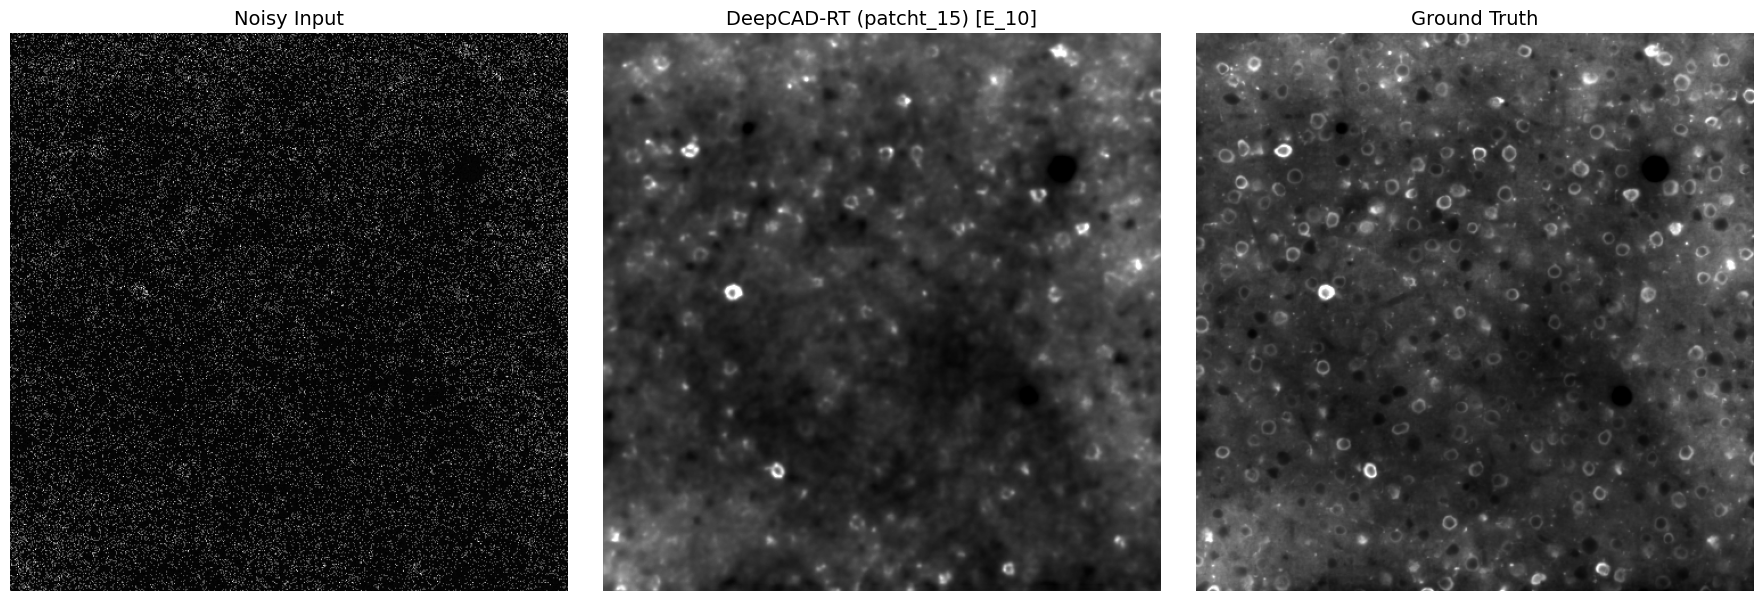

In [ ]:
x = Recording("dataset/synthetic/x.tiff", max_frames=2).normalized
gt = Recording("../dataset/zenodo/synthetic/clean_30Hz_490x490x6000.tif", max_frames=2).normalized
for k, files in evals.items():
    if len(files) <= 0:
        continue
    y = Recording(files[-1], max_frames=2).normalized
    imshow(
        {
            "Noisy Input": x[-1],
            f"DeepCAD-RT ({k}) [{files[-1].stem.split('_Iter')[0].replace('xf_','')}]": y[-1],
            "Ground Truth": gt[-1],
        },
        size=6,
        cmap="grey",
        vrange=(0, 1),
    )

The authors chose `patch_t = 150` as the default value because, as we can see here, it seems to be the optimum in terms of denoising quality.